# 03 - Distributions, Skewness, Sampling, and CLT


## 1) Learning Objectives

- Generate normal, uniform, Poisson, and skewed synthetic data.
- Explain distribution shape differences.
- Compute and interpret skewness.
- Demonstrate sampling variability and the Central Limit Theorem (CLT).

## 2) Why This Topic Matters

Statistics starts with understanding your data. If we skip inspection or mix up variable types, later analysis can become misleading.

## 3) Short and Simple Theory Explanation

- A **distribution** describes how values are spread.
- **Skewness** measures asymmetry (long tail on one side).
- **Sampling** means drawing random subsets from a population.
- **CLT:** sample means become more bell-shaped as sample size increases, even if the original population is skewed.

## 4) Step-by-Step Code Examples

### Step 4.1 — Setup

We use `numpy` to generate random numbers and `scipy.stats.skew` to measure skewness.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

np.random.seed(42)
sns.set_theme(style='whitegrid')
rng = np.random.default_rng(42)

### Step 4.2 — Generate four synthetic distributions

In [2]:
sample_size = 1000

normal_data = rng.normal(loc=50, scale=10, size=sample_size)
uniform_data = rng.uniform(low=0, high=100, size=sample_size)
poisson_data = rng.poisson(lam=8, size=sample_size)
skewed_data = rng.exponential(scale=15, size=sample_size)

distribution_table = pd.DataFrame({
    'distribution': ['Normal', 'Uniform', 'Poisson', 'Skewed (Exponential)'],
    'mean': [normal_data.mean(), uniform_data.mean(), poisson_data.mean(), skewed_data.mean()],
    'variance': [normal_data.var(), uniform_data.var(), poisson_data.var(), skewed_data.var()],
    'skewness': [skew(normal_data), skew(uniform_data), skew(poisson_data), skew(skewed_data)],
}).round(3)
distribution_table

,distribution,mean,variance,skewness
0,Normal,49.711,97.757,-0.044
1,Uniform,50.343,838.310,0.031
2,Poisson,7.909,8.213,0.474
3,Skewed (Exponential),15.187,229.792,2.265


**Interpretation:** Different generators create different shapes. Poisson data are counts (non-negative integers). Exponential data are right-skewed.

### Step 4.3 — Visualize each distribution with histograms

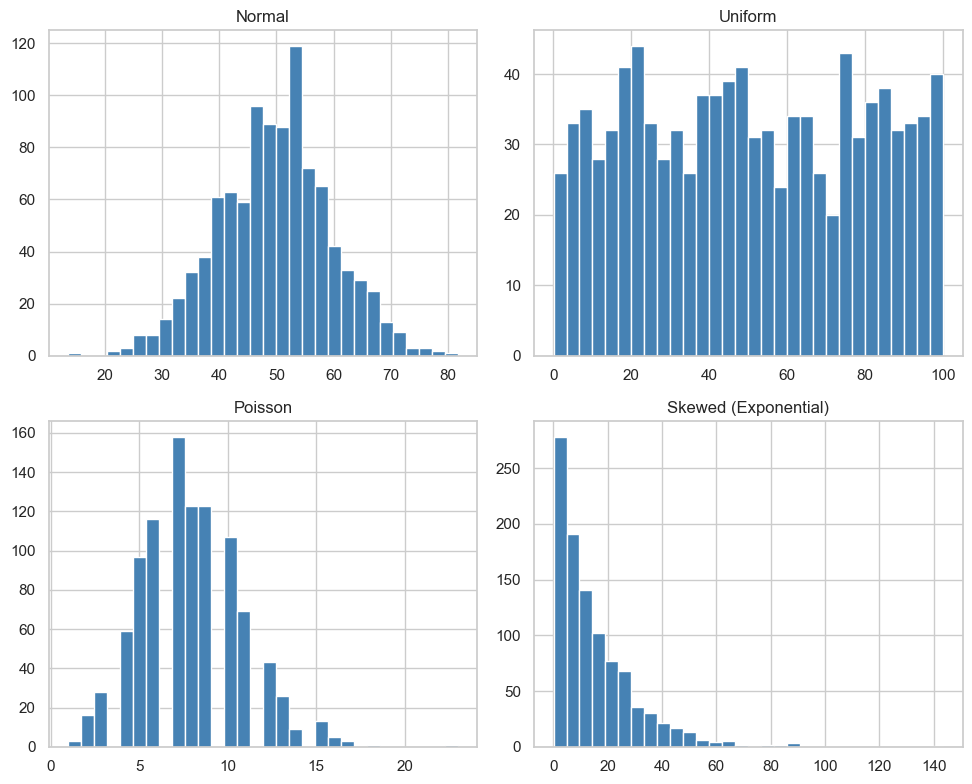

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
datasets = [
    (normal_data, 'Normal'),
    (uniform_data, 'Uniform'),
    (poisson_data, 'Poisson'),
    (skewed_data, 'Skewed (Exponential)'),
]
for ax, (values, title) in zip(axes.ravel(), datasets):
    ax.hist(values, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Interpretation:** Normal looks bell-shaped; uniform looks flat; skewed has a long right tail.

### Step 4.4 — Skewness values in plain language

In [4]:
for name, values in [('Normal', normal_data), ('Skewed', skewed_data)]:
    print(f"{name}: skewness = {skew(values):.3f}")

Normal: skewness = -0.044
Skewed: skewness = 2.265


**Interpretation:** Skewness near 0 suggests symmetry. Positive skewness means a longer right tail.

### Step 4.5 — Build a skewed population for CLT demo

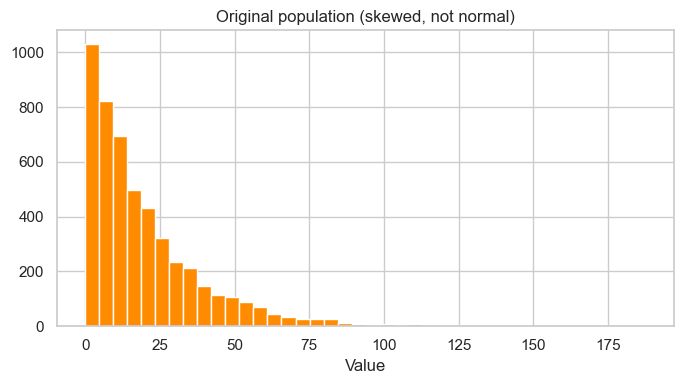

Population mean: 20.04


In [5]:
population = rng.exponential(scale=20, size=5000)
plt.figure(figsize=(7, 4))
plt.hist(population, bins=40, color='darkorange', edgecolor='white')
plt.title('Original population (skewed, not normal)')
plt.xlabel('Value')
plt.tight_layout()
plt.show()
print('Population mean:', round(population.mean(), 2))

### Step 4.6 — Sampling experiment and CLT

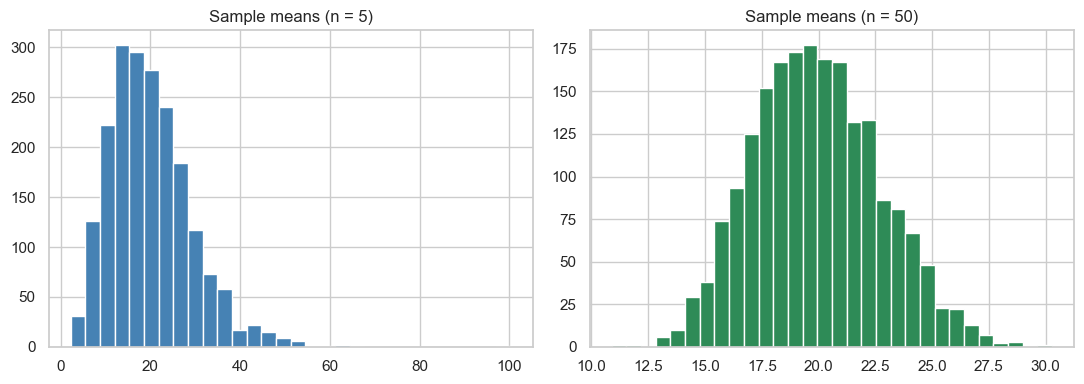

In [6]:
def sample_means(data, sample_size, number_of_samples):
    means = []
    for _ in range(number_of_samples):
        one_sample = rng.choice(data, size=sample_size, replace=True)
        means.append(one_sample.mean())
    return np.array(means)

small_sample_means = sample_means(population, sample_size=5, number_of_samples=2000)
large_sample_means = sample_means(population, sample_size=50, number_of_samples=2000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(small_sample_means, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Sample means (n = 5)')
axes[1].hist(large_sample_means, bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Sample means (n = 50)')
plt.tight_layout()
plt.show()

**Interpretation:** Even though the population is skewed, the distribution of sample means becomes more bell-shaped when sample size increases. That is the idea behind the CLT.

### Step 4.7 — Change sample size and observe

In [7]:
medium_sample_means = sample_means(population, sample_size=20, number_of_samples=2000)
clt_compare = pd.DataFrame({
    'sample_size': [5, 20, 50],
    'mean_of_sample_means': [small_sample_means.mean(), medium_sample_means.mean(), large_sample_means.mean()],
    'std_of_sample_means': [small_sample_means.std(), medium_sample_means.std(), large_sample_means.std()],
}).round(3)
clt_compare

,sample_size,mean_of_sample_means,std_of_sample_means
0,5,20.100,9.273
1,20,20.009,4.484
2,50,19.912,2.802


**Interpretation:** The mean of sample means stays near the population mean, while spread shrinks as sample size grows.

## 7) Summary Interpretation

We generated different distributions, measured skewness, and showed that sample means become more normal as sample size grows.

## 8) Student Check Questions

1. (Conceptual) What does the CLT say about sample means?

2. (Code) Change sample size to 100 and replot sample means.

In [8]:
# Question 2 — your code here


## 9) Key Takeaways

- Distributions describe how data are generated.
- Skewness helps describe asymmetry.
- Sampling introduces random variation.
- Larger samples give more stable mean estimates.

## 10) Optional Short Practice / Challenge

Add a binomial sample with `rng.binomial(n=20, p=0.3, size=1000)`.

## 11) Code Refinement Tasks

Edit the code, rerun each cell, and write one short sentence per task.

1. In CLT demo, use `sample_size=100`.
2. Change Poisson `lam` from 8 to 20 and recompute mean.

In [9]:
# Refinement 1


In [10]:
# Refinement 2


In [11]:
print('Notebook 03 completed successfully.')

Notebook 03 completed successfully.
